In [1]:
!pip install torch-pruning -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.6 MB/s eta 0:00:00


Device: cuda


100%|██████████| 169M/169M [00:01<00:00, 87.2MB/s]



 PHASE 1: PRETRAINING BASELINE
  [Pretrain] Epoch 1/100 | Loss 4.4614 | Acc 9.39%
  [Pretrain] Epoch 2/100 | Loss 3.8362 | Acc 16.03%
  [Pretrain] Epoch 3/100 | Loss 3.4953 | Acc 20.85%
  [Pretrain] Epoch 4/100 | Loss 3.1935 | Acc 25.06%
  [Pretrain] Epoch 5/100 | Loss 2.9256 | Acc 31.58%
  [Pretrain] Epoch 6/100 | Loss 2.7034 | Acc 34.15%
  [Pretrain] Epoch 7/100 | Loss 2.5334 | Acc 37.66%
  [Pretrain] Epoch 8/100 | Loss 2.3834 | Acc 39.67%
  [Pretrain] Epoch 9/100 | Loss 2.2633 | Acc 41.91%
  [Pretrain] Epoch 10/100 | Loss 2.1604 | Acc 42.74%
  [Pretrain] Epoch 11/100 | Loss 2.0668 | Acc 45.23%
  [Pretrain] Epoch 12/100 | Loss 1.9816 | Acc 47.17%
  [Pretrain] Epoch 13/100 | Loss 1.9079 | Acc 47.44%
  [Pretrain] Epoch 14/100 | Loss 1.8395 | Acc 48.98%
  [Pretrain] Epoch 15/100 | Loss 1.7787 | Acc 50.53%
  [Pretrain] Epoch 16/100 | Loss 1.5434 | Acc 54.75%
  [Pretrain] Epoch 17/100 | Loss 1.4824 | Acc 55.42%
  [Pretrain] Epoch 18/100 | Loss 1.4490 | Acc 55.30%
  [Pretrain] Epoch 19/10

Computing Taylor importance scores: 100%|██████████| 32/32 [00:02<00:00, 10.87it/s]


✅ Taylor scores computed for 81 Conv2d layers

 FILTER NOISE ANALYSIS: What gets pruned vs what survives
✅ Saved: /kaggle/working/filter_noise_analysis.png

 PHASE 2: STRUCTURED PRUNING
✅ ACCURACY AFTER PRUNING (no fine-tuning): 16.72%

 PHASE 3: WARMUP FINE-TUNING (Standard SGD)
  [Warmup] Epoch 1 | Acc 48.44%
  [Warmup] Epoch 2 | Acc 51.33%
  [Warmup] Epoch 3 | Acc 53.01%
  [Warmup] Epoch 4 | Acc 53.72%
  [Warmup] Epoch 5 | Acc 55.06%

 PHASE 4: IAFB IMPORTANCE-AWARE FINE-TUNING
  [IAFB] Epoch 1 | Acc 58.47%
  [IAFB] Epoch 2 | Acc 59.16%
  [IAFB] Epoch 3 | Acc 59.49%
  [IAFB] Epoch 4 | Acc 59.54%
  [IAFB] Epoch 5 | Acc 59.82%
  [IAFB] Epoch 6 | Acc 59.84%
  [IAFB] Epoch 7 | Acc 60.02%
  [IAFB] Epoch 8 | Acc 60.46%
  [IAFB] Epoch 9 | Acc 60.49%
  [IAFB] Epoch 10 | Acc 60.27%
  [IAFB] Epoch 11 | Acc 60.81%
  [IAFB] Epoch 12 | Acc 60.69%
  [IAFB] Epoch 13 | Acc 60.84%
  [IAFB] Epoch 14 | Acc 60.55%
  [IAFB] Epoch 15 | Acc 60.59%
  [IAFB] Epoch 16 | Acc 60.97%
  [IAFB] Epoch 17 | Acc 60.

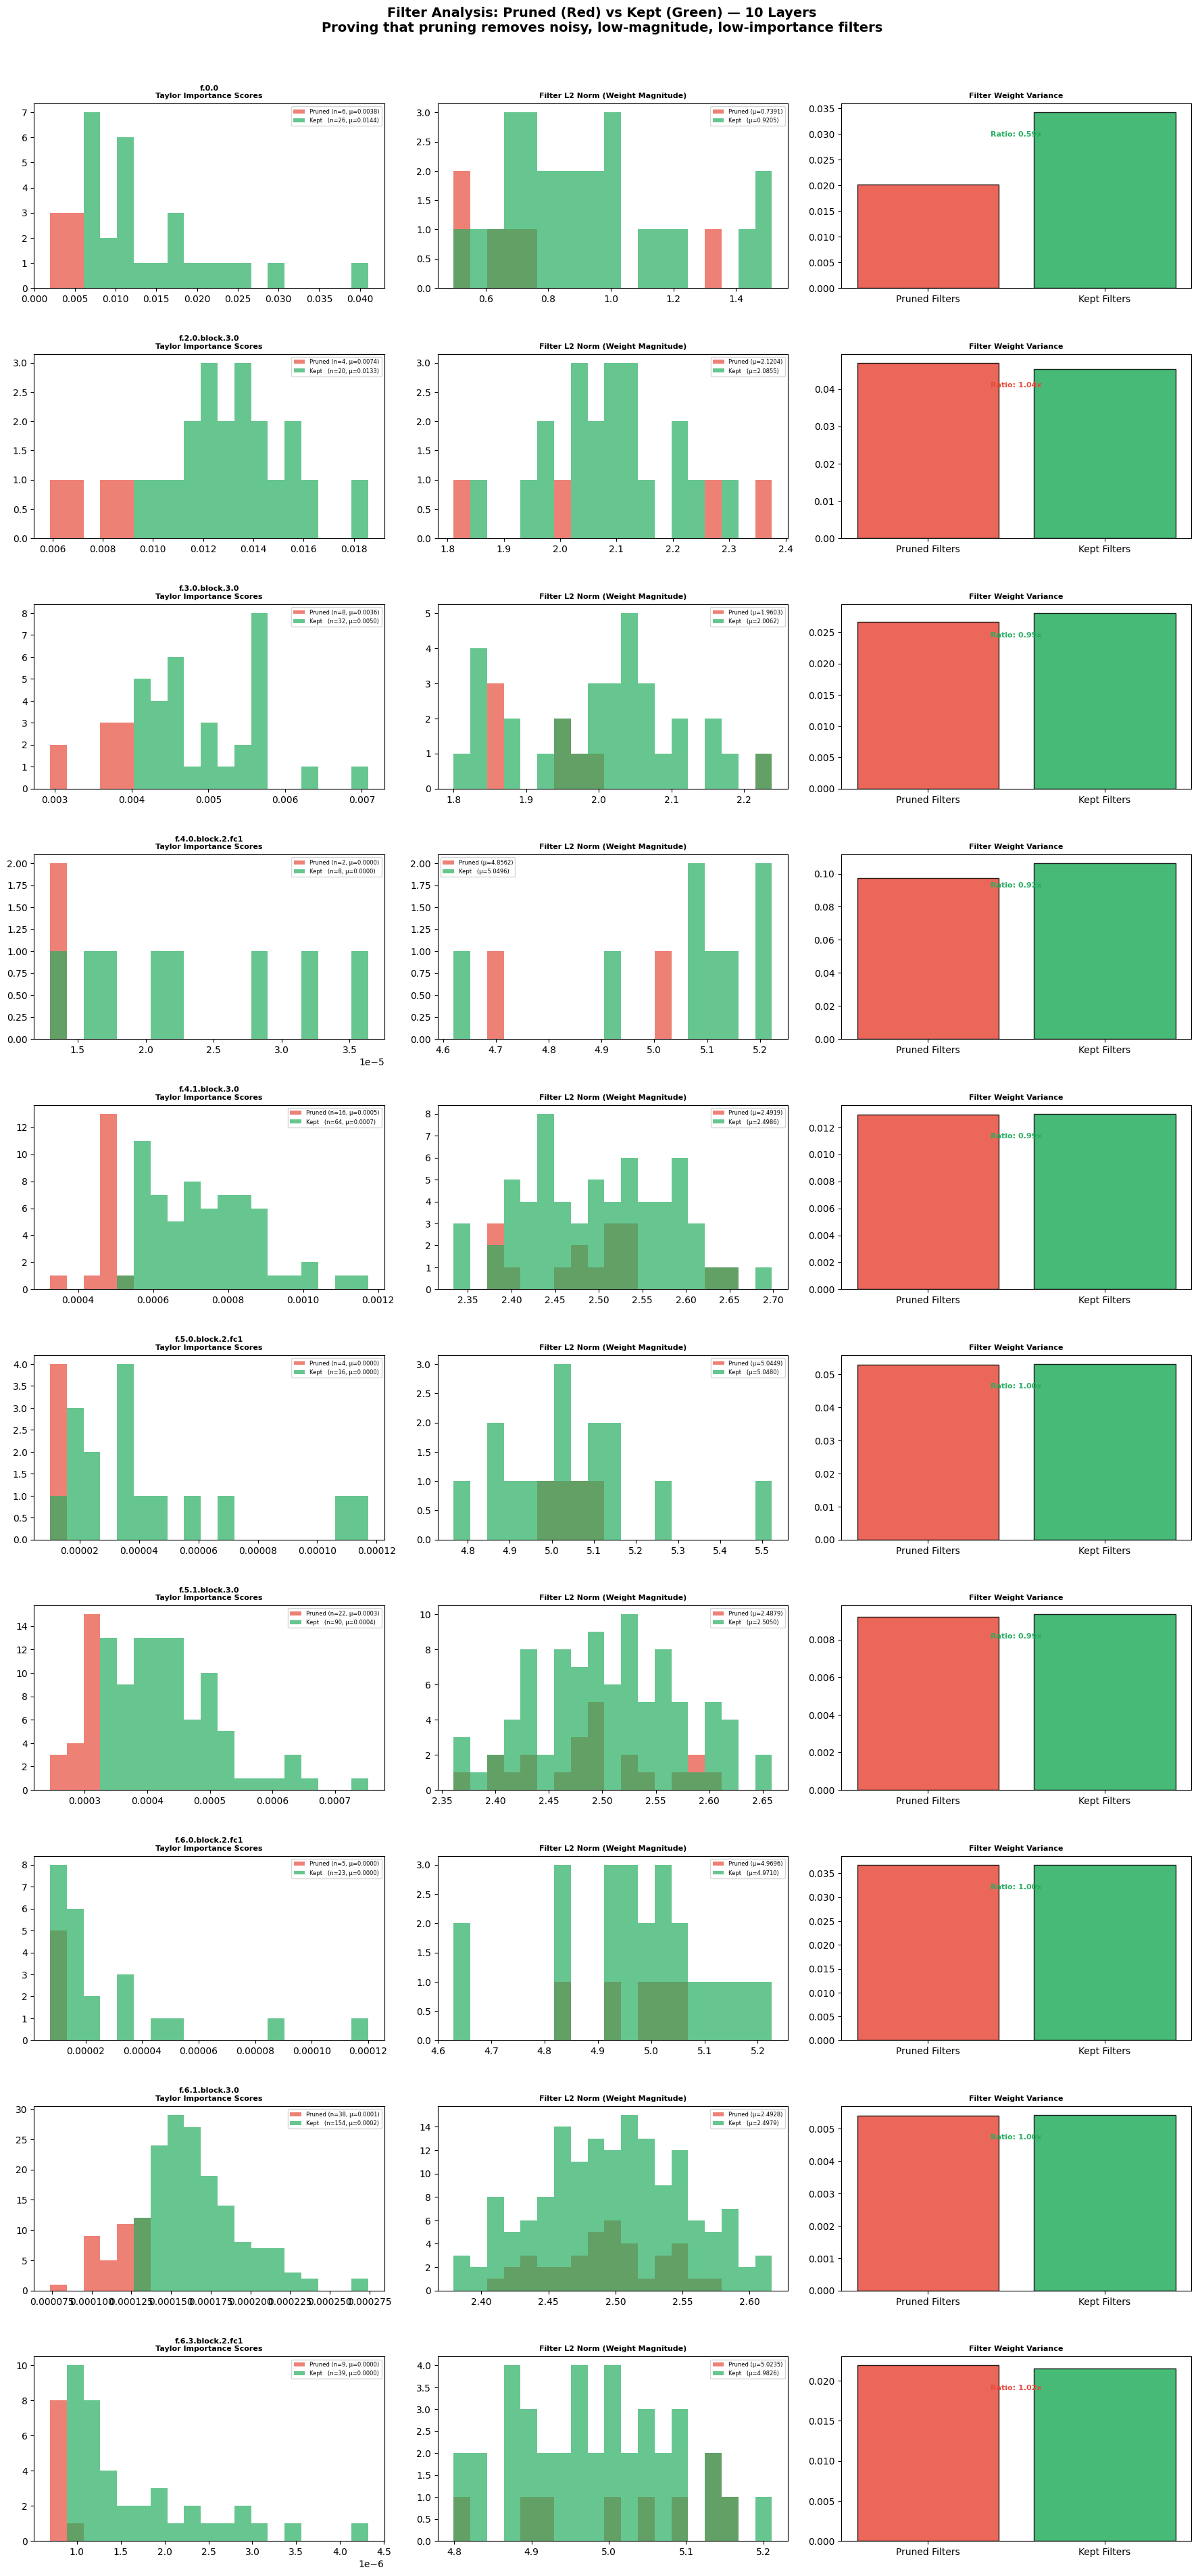

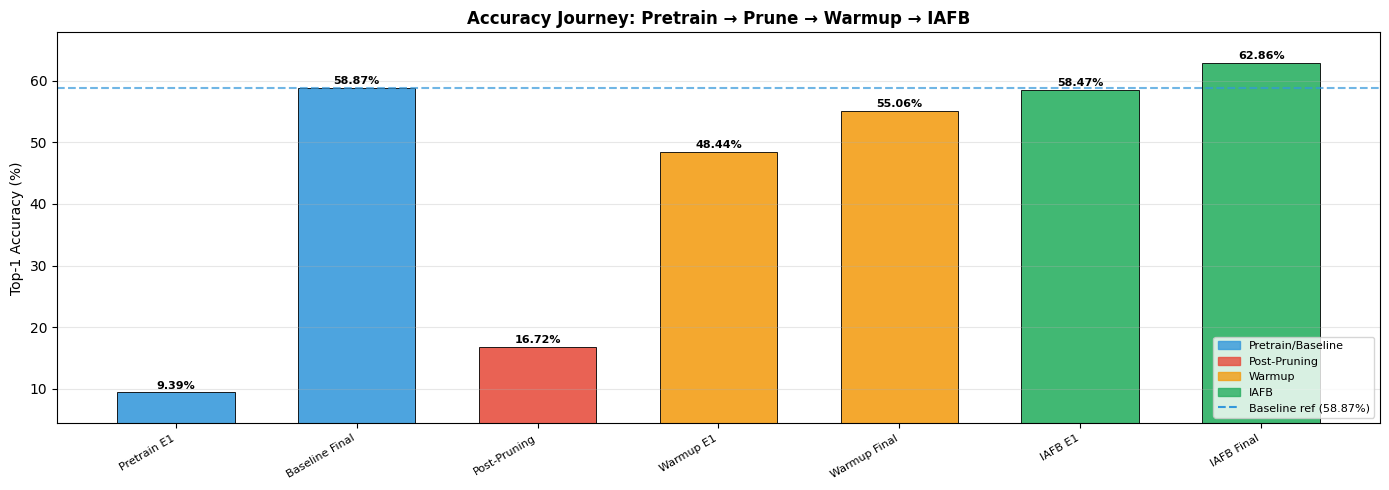

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torchvision.models import efficientnet_b0
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch_pruning as tp
import copy
from sklearn.metrics import precision_recall_fscore_support

# Make matplotlib work in Kaggle/Colab
import matplotlib
matplotlib.use('Agg')
%matplotlib inline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ==========================================
# 1. HYPERPARAMETERS & SETUP
# ==========================================
BATCH_SIZE      = 128
EPOCHS_PRETRAIN = 100       
EPOCHS_WARMUP   = 5      
EPOCHS_IAFB     = 75      
PRUNE_RATIO     = 0.2     
CALIB_SAMPLES   = 2000    
LR              = 0.01    
WEIGHT_DECAY    = 5e-4
IAFB_ALPHA      = 2.0     
IAFB_LR         = 0.005   

# Accuracy tracker — crucial for the final journey plot
accuracy_log = {}

train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_set = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ==========================================
# 2. MODEL BUILDING & UTILS
# ==========================================
def build_model():
    model = efficientnet_b0(num_classes=100)
    model.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    return model.to(DEVICE)

def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return correct / total

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

criterion = nn.CrossEntropyLoss()
model     = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25], gamma=0.1)

# ==========================================
# 3. PHASE 1: PRETRAINING BASELINE
# ==========================================
print("\n" + "=" * 55)
print(" PHASE 1: PRETRAINING BASELINE")
print("=" * 55)

best_pretrain_acc = 0
for epoch in range(EPOCHS_PRETRAIN):
    model.train()
    running_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    
    acc = evaluate(model)
    accuracy_log[f'pretrain_epoch_{epoch+1}'] = acc
    print(f"  [Pretrain] Epoch {epoch+1}/{EPOCHS_PRETRAIN} | Loss {running_loss/len(train_loader):.4f} | Acc {acc*100:.2f}%")
    if acc > best_pretrain_acc:
        best_pretrain_acc = acc
        torch.save(model.state_dict(), "/kaggle/working/effnet_baseline.pt")

baseline_acc = evaluate(model)
accuracy_log['baseline_final'] = baseline_acc
print(f"\n✅ BASELINE FINAL ACCURACY: {baseline_acc*100:.2f}%")

# ==========================================
# 4. PHASE 2: TAYLOR SCORES & NOISE ANALYSIS
# ==========================================
idx          = torch.randperm(len(train_set))[:CALIB_SAMPLES]
calib_loader = DataLoader(Subset(train_set, idx), batch_size=64)

activations, gradients = {}, {}

def fwd_hook(name):
    def hook(m, i, o): activations[name] = o.detach().clone()
    return hook

def bwd_hook(name):
    def hook(m, gi, go): gradients[name] = go[0].detach().clone()
    return hook

for m in model.modules():
    if isinstance(m, nn.SiLU): m.inplace = False

for name, m in model.named_modules():
    if isinstance(m, nn.Conv2d):
        m.register_forward_hook(fwd_hook(name))
        m.register_full_backward_hook(bwd_hook(name))

taylor = {}
model.eval()
for x, y in tqdm(calib_loader, desc="Computing Taylor importance scores"):
    x, y = x.to(DEVICE), y.to(DEVICE)
    loss = criterion(model(x), y)
    model.zero_grad()
    loss.backward()
    for k in activations:
        if k in gradients:
            score = torch.abs(activations[k] * gradients[k]).sum((2, 3))
            taylor.setdefault(k, []).append(score.cpu())

taylor_final = {k: torch.cat(v).median(0).values for k, v in taylor.items()}
print(f"✅ Taylor scores computed for {len(taylor_final)} Conv2d layers")

print("\n" + "=" * 60)
print(" FILTER NOISE ANALYSIS: What gets pruned vs what survives")
print("=" * 60)

candidate_layers = [(name, module) for name, module in model.named_modules()
                    if isinstance(module, nn.Conv2d) and module.groups == 1
                    and name in taylor_final and module.out_channels >= 8]

step = max(1, len(candidate_layers) // 10)
selected_layers = candidate_layers[::step][:10]

layer_stats = []
for name, module in selected_layers:
    imp    = taylor_final[name]
    n_ch   = module.out_channels
    n_prune = max(1, int(n_ch * PRUNE_RATIO))

    sorted_idx  = torch.argsort(imp)
    pruned_idx  = sorted_idx[:n_prune]
    kept_idx    = sorted_idx[n_prune:]

    W = module.weight.data.cpu()
    pruned_filters = W[pruned_idx]
    kept_filters   = W[kept_idx]

    pruned_var = pruned_filters.view(pruned_filters.size(0), -1).var(dim=1).mean().item()
    kept_var   = kept_filters.view(kept_filters.size(0),   -1).var(dim=1).mean().item()
    pruned_norm = pruned_filters.view(pruned_filters.size(0), -1).norm(dim=1).mean().item()
    kept_norm   = kept_filters.view(kept_filters.size(0),   -1).norm(dim=1).mean().item()
    
    pruned_score = imp[pruned_idx].mean().item()
    kept_score   = imp[kept_idx].mean().item()
    var_ratio = pruned_var / (kept_var + 1e-12)

    layer_stats.append({
        'name': name.replace('features.', 'f.'), 'n_ch': n_ch, 'n_prune': n_prune,
        'pruned_var': pruned_var, 'kept_var': kept_var, 'var_ratio': var_ratio,
        'pruned_norm': pruned_norm, 'kept_norm': kept_norm,
        'pruned_score': pruned_score, 'kept_score': kept_score,
        'pruned_imp': imp[pruned_idx].numpy(), 'kept_imp': imp[kept_idx].numpy(),
        'pruned_norms_all': pruned_filters.view(pruned_filters.size(0), -1).norm(dim=1).numpy(),
        'kept_norms_all':   kept_filters.view(kept_filters.size(0),   -1).norm(dim=1).numpy(),
    })

avg_var_ratio = np.mean([s['var_ratio'] for s in layer_stats])
avg_pruned_norm = np.mean([s['pruned_norm'] for s in layer_stats])
avg_kept_norm   = np.mean([s['kept_norm'] for s in layer_stats])

# Visualization
fig, axes = plt.subplots(10, 3, figsize=(18, 38))
fig.suptitle('Filter Analysis: Pruned (Red) vs Kept (Green) — 10 Layers\nProving that pruning removes noisy, low-magnitude, low-importance filters', fontsize=14, fontweight='bold', y=1.005)

for row, stats in enumerate(layer_stats):
    layer_label = stats['name']
    ax1, ax2, ax3 = axes[row]

    bins = np.linspace(min(stats['pruned_imp'].min(), stats['kept_imp'].min()), max(stats['pruned_imp'].max(), stats['kept_imp'].max()), 20)
    ax1.hist(stats['pruned_imp'], bins=bins, alpha=0.7, color='#e74c3c', label=f"Pruned (n={stats['n_prune']}, μ={stats['pruned_score']:.4f})")
    ax1.hist(stats['kept_imp'],   bins=bins, alpha=0.7, color='#27ae60', label=f"Kept   (n={stats['n_ch']-stats['n_prune']}, μ={stats['kept_score']:.4f})")
    ax1.set_title(f"{layer_label}\nTaylor Importance Scores", fontsize=8, fontweight='bold')
    ax1.legend(fontsize=6)

    all_norms = np.concatenate([stats['pruned_norms_all'], stats['kept_norms_all']])
    bins2 = np.linspace(all_norms.min(), all_norms.max(), 20)
    ax2.hist(stats['pruned_norms_all'], bins=bins2, alpha=0.7, color='#e74c3c', label=f"Pruned (μ={stats['pruned_norm']:.4f})")
    ax2.hist(stats['kept_norms_all'],   bins=bins2, alpha=0.7, color='#27ae60', label=f"Kept   (μ={stats['kept_norm']:.4f})")
    ax2.set_title(f"Filter L2 Norm (Weight Magnitude)", fontsize=8, fontweight='bold')
    ax2.legend(fontsize=6)

    bars = ax3.bar(['Pruned Filters', 'Kept Filters'], [stats['pruned_var'], stats['kept_var']], color=['#e74c3c', '#27ae60'], alpha=0.85, edgecolor='black')
    ax3.set_title(f"Filter Weight Variance", fontsize=8, fontweight='bold')
    color_r = '#e74c3c' if stats['var_ratio'] >= 1.0 else '#27ae60'
    ax3.text(0.5, 0.85, f"Ratio: {stats['var_ratio']:.2f}x", ha='center', va='top', transform=ax3.transAxes, fontsize=8, fontweight='bold', color=color_r)

plt.tight_layout(pad=2.0)
plt.savefig('/kaggle/working/filter_noise_analysis.png', dpi=130, bbox_inches='tight', facecolor='white')
print("✅ Saved: /kaggle/working/filter_noise_analysis.png")


# ==========================================
# 5. PHASE 2: STRUCTURED PRUNING
# ==========================================
def prune_model(model, importance_dict):
    model = copy.deepcopy(model).to(DEVICE)
    model.eval()

    for m in model.modules():
        if isinstance(m, nn.SiLU): m.inplace = False

    example_inputs = torch.randn(1, 3, 32, 32).to(DEVICE)
    DG = tp.DependencyGraph().build_dependency(model, example_inputs=example_inputs)

    original_out_channels = {m: m.out_channels for m in model.modules() if isinstance(m, nn.Conv2d)}
    pruned_count, total_removed = 0, 0
    
    for name, module in model.named_modules():
        if not isinstance(module, nn.Conv2d) or module.groups != 1 or name not in importance_dict: continue
        if module.out_channels < original_out_channels[module]: continue

        imp          = importance_dict[name].to(DEVICE)
        out_channels = module.out_channels
        keep         = max(int(out_channels * (1 - PRUNE_RATIO)), 1)
        prune_n      = out_channels - keep
        
        if prune_n <= 0: continue

        idx   = torch.argsort(imp)[:prune_n].tolist()
        group = DG.get_pruning_group(module, tp.prune_conv_out_channels, idxs=idx)
        if DG.check_pruning_group(group):
            group.prune()
            pruned_count  += 1
            total_removed += prune_n

    return model

print("\n" + "=" * 55)
print(" PHASE 2: STRUCTURED PRUNING")
print("=" * 55)

params_before = count_params(model)
pruned_model  = prune_model(model, taylor_final)
params_after  = count_params(pruned_model)

post_prune_acc = evaluate(pruned_model)
accuracy_log['post_pruning'] = post_prune_acc
print(f"✅ ACCURACY AFTER PRUNING (no fine-tuning): {post_prune_acc*100:.2f}%")


# ==========================================
# 6. PHASE 3: WARMUP FINE-TUNING
# ==========================================
print("\n" + "=" * 55)
print(" PHASE 3: WARMUP FINE-TUNING (Standard SGD)")
print("=" * 55)

optimizer_warmup = torch.optim.SGD(pruned_model.parameters(), lr=LR, momentum=0.9, weight_decay=WEIGHT_DECAY)

for epoch in range(EPOCHS_WARMUP):
    pruned_model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer_warmup.zero_grad()
        loss = criterion(pruned_model(x), y)
        loss.backward()
        optimizer_warmup.step()
        total_loss += loss.item()
    
    acc = evaluate(pruned_model)
    accuracy_log[f'warmup_epoch_{epoch+1}'] = acc
    print(f"  [Warmup] Epoch {epoch+1} | Acc {acc*100:.2f}%")

warmup_acc = evaluate(pruned_model)
accuracy_log['warmup_final'] = warmup_acc


# ==========================================
# 7. PHASE 4: IAFB FINE-TUNING
# ==========================================
def compute_iafb_importance(model):
    importance_map = {}
    for name, param in model.named_parameters():
        if not param.requires_grad: continue
        imp = param.data.abs()
        if imp.max() > 0: imp = imp / imp.max()
        importance_map[name] = imp.detach().clone()
    return importance_map

importance_map = compute_iafb_importance(pruned_model)
all_imp_vals = torch.cat([v.flatten() for v in importance_map.values()]).cpu().numpy()

def iafb_train_epoch(model, dataloader, importance_map, lr, alpha):
    model.train()
    total_loss = 0
    for x, y in dataloader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        outputs = model(x)
        loss    = criterion(outputs, y)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            for name, param in model.named_parameters():
                if param.grad is None: continue
                if name in importance_map:
                    imp = importance_map[name]
                    if imp.shape != param.shape:
                        imp = param.data.abs()
                        if imp.max() > 0: imp = imp / imp.max()
                    scaling = (1.0 - imp).pow(alpha)
                    param.data -= lr * scaling * param.grad
                else:
                    param.data -= lr * param.grad
        total_loss += loss.item()
    return total_loss / len(dataloader)

print("\n" + "=" * 55)
print(" PHASE 4: IAFB IMPORTANCE-AWARE FINE-TUNING")
print("=" * 55)

best_iafb_acc = 0
for epoch in range(EPOCHS_IAFB):
    avg_loss = iafb_train_epoch(pruned_model, train_loader, importance_map, IAFB_LR, IAFB_ALPHA)
    acc = evaluate(pruned_model)
    accuracy_log[f'iafb_epoch_{epoch+1}'] = acc
    print(f"  [IAFB] Epoch {epoch+1} | Acc {acc*100:.2f}%")
    if acc > best_iafb_acc:
        best_iafb_acc = acc
        torch.save(pruned_model.state_dict(), "/kaggle/working/effnet_iafb_best.pt")

accuracy_log['iafb_final'] = best_iafb_acc


# ==========================================
# 8. VISUALIZATION: ACCURACY JOURNEY
# ==========================================
print("\nGenerating Accuracy Journey Plot...")

# 1. Defining the baseline reference point
baseline_ref = accuracy_log['baseline_final']

# 2. Extracting the journey stages dynamically based on logs
final_stages = [
    ('pretrain_epoch_1', 'Pretrain E1'),
    ('baseline_final',   'Baseline Final'),
    ('post_pruning',     'Post-Pruning'),
    ('warmup_epoch_1',   'Warmup E1'),
    ('warmup_final',     'Warmup Final'),
    ('iafb_epoch_1',     'IAFB E1'),
    ('iafb_final',       'IAFB Final')
]

# Ensure we only plot stages that exist in the log (handles varying epochs)
final_stages = [(k, label) for k, label in final_stages if k in accuracy_log]

labels = [label for _, label in final_stages]
accs   = [accuracy_log[k] * 100 for k, _ in final_stages]

fig, ax = plt.subplots(figsize=(14, 5))

colors = []
for k, _ in final_stages:
    if 'pretrain' in k or 'baseline' in k: colors.append('#3498db')
    elif 'pruning' in k:                   colors.append('#e74c3c')
    elif 'warmup' in k:                    colors.append('#f39c12')
    else:                                  colors.append('#27ae60')

bars = ax.bar(range(len(accs)), accs, color=colors, alpha=0.88, edgecolor='black', linewidth=0.7, width=0.65)

for i, (bar, val) in enumerate(zip(bars, accs)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.axhline(y=baseline_ref*100, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Baseline ({baseline_ref*100:.2f}%)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=10)
ax.set_title('Accuracy Journey: Pretrain → Prune → Warmup → IAFB', fontsize=12, fontweight='bold')
ax.set_ylim(max(0, min(accs) - 5), min(100, max(accs) + 5))
ax.grid(axis='y', alpha=0.3)

phase_colors = {'Pretrain/Baseline': '#3498db', 'Post-Pruning': '#e74c3c', 'Warmup': '#f39c12', 'IAFB': '#27ae60'}
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=l, alpha=0.8) for l, c in phase_colors.items()]
ax.legend(handles=legend_patches + [plt.Line2D([0], [0], color='#3498db', linestyle='--', linewidth=1.5, label=f'Baseline ref ({baseline_ref*100:.2f}%)')], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('/kaggle/working/accuracy_journey.png', dpi=130, bbox_inches='tight', facecolor='white')
print("✅ Saved: /kaggle/working/accuracy_journey.png")
print("✅ Saved: /kaggle/working/effnet_iafb_best.pt")